<a href="https://colab.research.google.com/github/mandaw34/BigData26_A_2411533009_Devina-Amanda-P/blob/main/Praktikum1/BD_A_P01_2411533009_Devina_Amanda_Putri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**J-1. Verifikasi lingkungan kerja**

Bertujuan untuk mendokumentasikan spesifikasi hardware, versi Python, serta kestabilan pustaka utama yang terpasang pada runtime Google Colab. Informasi ini penting untuk memastikan seluruh pustaka pendukung siap digunakan dan hasilnya dapat direproduksi dengan tepat.

In [1]:
import sys, platform, multiprocessing
print("Python   :", sys.version.split()[0])
print("OS       :", platform.platform())
print("CPU core :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

!free -h
!df -h /content
!java -version

Python   : 3.13.15
OS       : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       966Mi       8.9Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.026s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.026s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


**J-2. Menghubungkan Google Drive dan menyiapkan struktur folder**

menghubungkan Google Drive ke ruang kerja Colab serta membuat direktori penyimpanan sementara dan permanen. Jalur direktori permanen disesuaikan menggunakan variabel DIR_SIMPAN agar seluruh artefak hasil praktikum tersimpan dengan aman.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['yellow_tripdata_2023-01.parquet', 'trips.csv', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png', 'studi_kasus_penjadwalan.png']


**J-3. Menyiapkan alat ukur waktu dan memori**

mendefinisikan fungsi pembantu untuk memantau durasi eksekusi dan perubahan memori fisik (RSS) saat proses komputasi berlangsung. Fungsi ukur() akan mencatat metrik kinerja setiap langkah ke dalam list catatan untuk dianalisis kelak.

In [3]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS delta: {delta:+.1f} MB")
    return hasil

**J-4. Mengunduh dataset dan inspeksi awal**

mengunduh file Parquet perjalanan taksi NYC secara terprogram dari URL publik ke penyimpanan lokal. Selanjutnya, metadata file dibaca tanpa memuat seluruh isi dataset ke RAM untuk mengecek dimensi serta struktur kolomnya.

In [4]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq
meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

[unduh dataset] 0.23 s | RSS delta: +1.8 MB
Ukuran file: 45.5 MB
Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


**J-5. Memuat data dan mengukur biaya memorinya**

membandingkan penggunaan memori antara memuat seluruh kolom dataset versus memuat kolom tertentu (column projection). Dilakukan pula optimasi penghematan RAM dengan mengubah tipe data kolom menjadi tipe data yang lebih ringkas (downcasting dan category).

In [5]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

df.head()
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2 # MB per kolom

sebelum = df.memory_usage(deep=True).sum() / 1024**2
df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

[baca semua kolom] 1.45 s | RSS delta: +481.7 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.57 s | RSS delta: +221.8 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB
187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


**J-6. Pemeriksaan kualitas data dan pembersihan (veracity)**

mengidentifikasi data yang tidak valid, seperti durasi perjalanan bernilai negatif, jarak nol, atau tarif minus. Baris-baris yang mengandung anomali tersebut akan disaring sehingga menghasilkan dataset bersih yang siap dianalisis.

In [6]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                      df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"         : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"        : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit" : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"  : (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)
3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


**J-7. Memproses file lebih besar dari memori dengan chunking**

mensimulasikan pemrosesan file besar menggunakan teknik chunking pada format CSV uncompressed. Dengan membaca file bagian per bagian (out-of-core), penggunaan RAM tetap terjaga stabil meski total data yang diproses berukuran sangat besar.

In [7]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))
print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 48.57 s | RSS delta: +5.2 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 6.89 s | RSS delta: +20.0 MB
2,986,911 baris | rata-rata total_amount = 27.33


**J-8. Pendekatan terdistribusi: PySpark local mode**

mengimplementasikan pemrosesan data terdistribusi menggunakan PySpark pada mode lokal. Langkah ini menunjukkan bagaimana operasi filter, agregasi, hingga pengeksekusian kueri SQL dilakukan menggunakan engine Spark beserta evaluasi rencana eksekusinya (execution plan).

In [8]:
import warnings
warnings.filterwarnings('ignore')

!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
        - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
SELECT payment_type,
       COUNT(*)                   AS jumlah,
       ROUND(AVG(total_amount), 2) AS rata_tarif,
       ROUND(AVG(tip_amount), 2)   AS rata_tip
FROM trips
GROUP BY payment_type
ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spa

**Diagnosis & Refleksi Kendala (J-8)**:

pada eksekusi awal, cell ini sempat mengalami error TypeError: 'JavaPackage' object is not callable dan NameError: name 'PATH' is not defined. Setelah dianalisis, penyebab utamanya adalah ketidaksesuaian antara runtime python 3.13 bawaan google colab dengan versi java default dan pyspark 3.5.1, serta variabel path dataset yang belum terdefinisi di memori session saat itu.

percobaan penyelesaian dilakukan dengan melakukan restart session runtime, mereset environment Java agar kompatibel, serta memastikan urutan pengunduhan dataset dan pendefinisian variabel PATH dieksekusi secara runtut sebelum pembacaan .parquet. Setelah alur eksekusi dirapikan dari awal, SparkSession berhasil diinisialisasi dan seluruh operasi agregasi DataFrame maupun Spark SQL berjalan lancar tanpa kendala.

**J-9. Agregasi akhir dengan pandas dan penyimpanan artefak**

ringkasan statistik perjalanan per jam mengukur rata-rata serta nilai tengahnya menggunakan pandas. Hasil agregasi dan catatan performa kemudian disimpan secara permanen ke Google Drive dalam format CSV dan Parquet menggunakan variabel DIR_SIMPAN.

In [9]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


**J-10. Visualisasi hasil**

menampilkan grafik batang distribusi total perjalanan taksi berdasarkan jam penjemputan

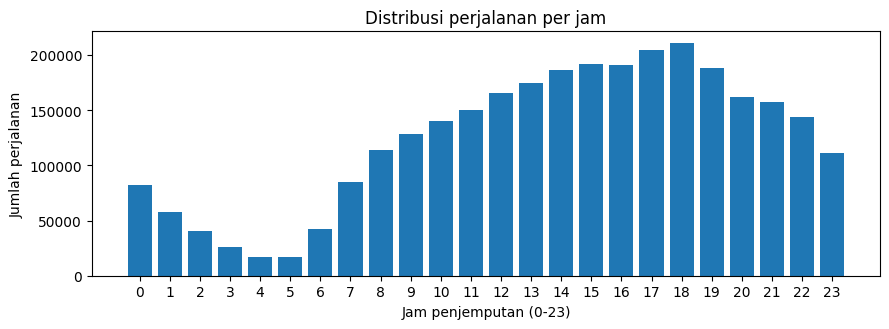

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

**STUDI KASUS**

Mengekstrak nama hari, menandai akhir pekan (weekend), serta menghitung metrik efisiensi ekonomi (tarif per menit), serta dilakukan agregasi data dengan mengelompokkan total volume perjalanan, rata-rata durasi,
dan profitabilitas berdasarkan kategori hari dan jam operasional.

In [11]:
# penambahan fitur dimensi hari dan tarif per menit
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

# agregasi data berdasarkan akhir_pekan dan jam
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

# 12 baris pertama
ringkas.head(12)

,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,False,0,35351,14.10,2.57
1,False,1,17516,13.04,2.66
2,False,2,9452,12.23,2.63
3,False,3,6238,12.87,2.72
4,False,4,6192,14.79,2.81
5,False,5,12462,14.63,2.82
6,False,6,35728,14.57,2.33
7,False,7,74157,14.66,2.07
8,False,8,98431,14.82,1.90
9,False,9,103263,15.03,1.90


Membuat plot perbandingan untuk melihat kontras pola
permintaan (rush hour hari kerja vs akhir pekan) serta tingkat profitabilitas
perjalanan guna mengoptimalkan strategi penempatan armada taksi.

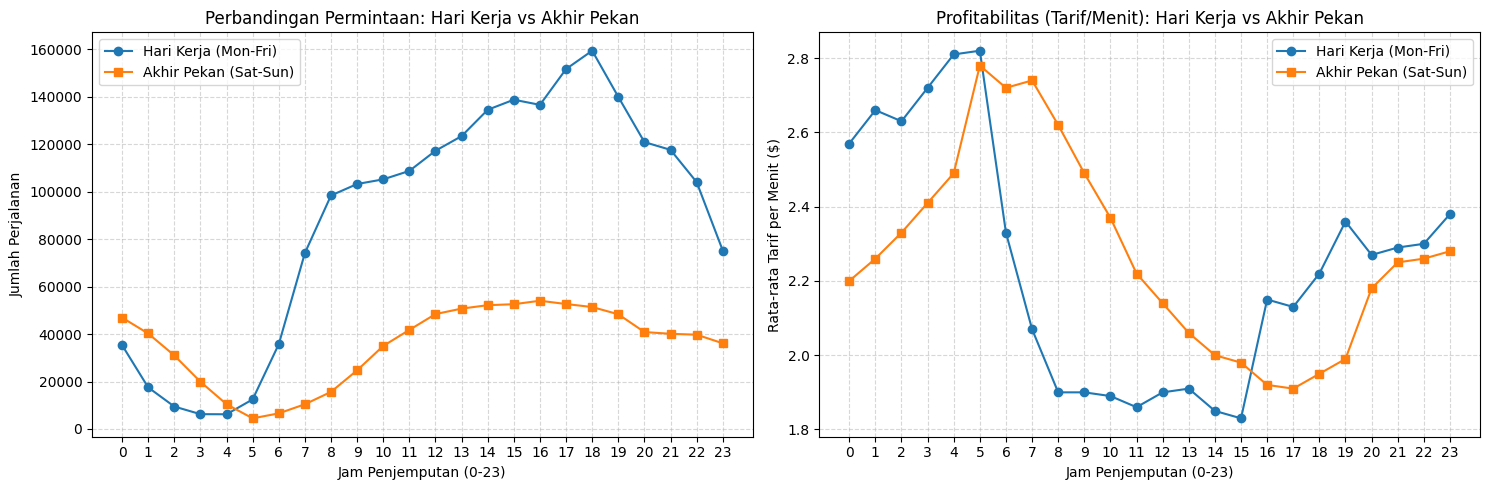

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# pisahkan data hari kerja dan akhir pekan
hari_kerja = ringkas[ringkas["akhir_pekan"] == False]
akhir_pekan = ringkas[ringkas["akhir_pekan"] == True]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# grafik 1: Perbandingan Jumlah Perjalanan (Permintaan) per Jam
axes[0].plot(hari_kerja["jam"], hari_kerja["jumlah"], label="Hari Kerja (Mon-Fri)", marker='o', color='tab:blue')
axes[0].plot(akhir_pekan["jam"], akhir_pekan["jumlah"], label="Akhir Pekan (Sat-Sun)", marker='s', color='tab:orange')
axes[0].set_xlabel("Jam Penjemputan (0-23)")
axes[0].set_ylabel("Jumlah Perjalanan")
axes[0].set_title("Perbandingan Permintaan: Hari Kerja vs Akhir Pekan")
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# grafik 2: Perbandingan Profitabilitas (Tarif per Menit) per Jam
axes[1].plot(hari_kerja["jam"], hari_kerja["rata_tarif_per_menit"], label="Hari Kerja (Mon-Fri)", marker='o', color='tab:blue')
axes[1].plot(akhir_pekan["jam"], akhir_pekan["rata_tarif_per_menit"], label="Akhir Pekan (Sat-Sun)", marker='s', color='tab:orange')
axes[1].set_xlabel("Jam Penjemputan (0-23)")
axes[1].set_ylabel("Rata-rata Tarif per Menit ($)")
axes[1].set_title("Profitabilitas (Tarif/Menit): Hari Kerja vs Akhir Pekan")
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_penjadwalan.png", dpi=150)
plt.show()

**LATIHAN**

**Latihan 1: Top 5 trip_distance**

Kode program berikut ini menggunakan fungsi nlargest() untuk mencari dan menampilkan 5 baris data teratas dengan nilai trip_distance terbesar dari DataFrame bersih

Dari output dapat terlihat nilai jarak perjalanan terbesar mencapai 96,70 mil, yang masih berada dalam batas logis untuk perjalanan taksi jarak jauh

In [13]:
top5_jarak = bersih.nlargest(5, "trip_distance")
print("=== Versi A: Top 5 trip_distance dari DataFrame 'bersih' Praktikum ===")
display(top5_jarak)

=== Versi A: Top 5 trip_distance dari DataFrame 'bersih' Praktikum ===


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


**Latihan 2: Variasi chunksize pada Chunking**

Kode program berikut ini bertujuan meningkatkan chunksize dari 100.000 menjadi 1.000.000 mempercepat waktu pemrosesan I/O karena mengurangi jumlah iterasi overhead loop, namun menuntut penggunaan memori RAM (delta RSS) yang lebih tinggi.

In [14]:
import time
import psutil
import pandas as pd

def ukur_chunking(chunk_size):
    proses = psutil.Process()
    rss_awal = proses.memory_info().rss / 1e6
    t0 = time.time()

    total_rows = 0
    total_amount_sum = 0

    for chunk in pd.read_csv(f"{DIR_SIMPAN}/trips.csv", chunksize=chunk_size):
        total_rows += len(chunk)
        total_amount_sum += chunk["total_amount"].sum()

    durasi = time.time() - t0
    rss_akhir = proses.memory_info().rss / 1e6
    delta_rss = rss_akhir - rss_awal

    return durasi, delta_rss

durasi_100k, mem_100k = ukur_chunking(100_000)
durasi_1m, mem_1m = ukur_chunking(1_000_000)

print(f"chunksize=100_000   -> Waktu: {durasi_100k:.2f} s | Delta RSS: {mem_100k:+.2f} MB")
print(f"chunksize=1_000_000 -> Waktu: {durasi_1m:.2f} s | Delta RSS: {mem_1m:+.2f} MB")

chunksize=100_000   -> Waktu: 8.08 s | Delta RSS: +102.57 MB
chunksize=1_000_000 -> Waktu: 5.08 s | Delta RSS: +157.77 MB


**Latihan 3: Analisis persen_tip per payment_type**

Kode ini membuat kolom persentase tip (persen_tip) dengan pengaman pembagian nol, lalu menghitung rata-ratanya berdasarkan metode pembayaran (payment_type).


In [15]:
import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] == 0,
    0.0,
    (bersih["tip_amount"] / bersih["fare_amount"]) * 100
)

rata_tip_payment = bersih.groupby("payment_type")["persen_tip"].mean().round(2).reset_index()
print(rata_tip_payment)

  payment_type  persen_tip
0            0   20.219999
1            1   25.910000
2            2    0.000000
3            3    0.020000
4            4    0.150000


Dugaan Perbedaan Metode Pembayaran:

Pengemudi menerima persentase tip signifikan pada transaksi kartu kredit (payment_type=1) karena adanya prompt tip otomatis di mesin EDC, sedangkan transaksi tunai (payment_type=2) tercatat 0% tip akibat tip tunai diberikan langsung secara fisik tanpa tercatat pada argo sistem.

**Latihan 4: Kompresi Parquet (snappy vs gzip)**

Kode ini menyimpan DataFrame bersih ke format Parquet menggunakan dua algoritma kompresi berbeda (snappy dan gzip) untuk membandingkan ukuran file dan kecepatan tulisnya.

Algoritma snappy unggul dari segi kecepatan waktu tulis, sementara gzip menawarkan efisiensi ukuran file yang lebih kecil dengan konsekuensi waktu proses yang sedikit lebih lama.

In [16]:
import os
import time

# simpan Snappy
t0 = time.time()
bersih.to_parquet(f"{DIR_SIMPAN}/bersih_snappy.parquet", compression="snappy")
waktu_snappy = time.time() - t0
size_snappy = os.path.getsize(f"{DIR_SIMPAN}/bersih_snappy.parquet") / 1e6

# simpan Gzip
t0 = time.time()
bersih.to_parquet(f"{DIR_SIMPAN}/bersih_gzip.parquet", compression="gzip")
waktu_gzip = time.time() - t0
size_gzip = os.path.getsize(f"{DIR_SIMPAN}/bersih_gzip.parquet") / 1e6

print(f"Snappy -> Ukuran File: {size_snappy:.2f} MB | Waktu Tulis: {waktu_snappy:.2f} s")
print(f"Gzip   -> Ukuran File: {size_gzip:.2f} MB | Waktu Tulis: {waktu_gzip:.2f} s")

Snappy -> Ukuran File: 79.16 MB | Waktu Tulis: 2.68 s
Gzip   -> Ukuran File: 58.72 MB | Waktu Tulis: 75.14 s


**Latihan 5: Agregasi Spark SQL vs pandas J-9**

Kode ini menjalankan agregasi per jam menggunakan Spark SQL pada DataFrame terdistribusi, lalu membandingkan hasilnya secara terprogram dengan pandas untuk menguji konsistensi.

In [18]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Latihan5_Fix").getOrCreate()

# registrasi DataFrame Spark sebagai Temporary View
df_spark_bersih = spark.createDataFrame(bersih)
df_spark_bersih.createOrReplaceTempView("trips_cleaned")

# agregasi per jam menggunakan Spark SQL
spark_sql_agg = spark.sql("""
    SELECT
        hour(tpep_pickup_datetime) AS jam,
        COUNT(1) AS jumlah_spark
    FROM trips_cleaned
    GROUP BY hour(tpep_pickup_datetime)
    ORDER BY jam
""").toPandas()

# ambil data agregasi pandas J-9
pandas_agg = bersih.groupby(bersih["tpep_pickup_datetime"].dt.hour).size().reset_index(name="jumlah_pandas")
pandas_agg.rename(columns={"tpep_pickup_datetime": "jam"}, inplace=True)

# verifikasi Selisih Maksimum secara Terprogram
gabung = pd.merge(spark_sql_agg, pandas_agg, on="jam")
selisih_maks = (gabung["jumlah_spark"] - gabung["jumlah_pandas"]).abs().max()

print(f"Selisih maksimum antara Spark SQL dan pandas: {selisih_maks}")
assert selisih_maks == 0, "Ada perbedaan hasil antara Spark SQL dan pandas!"
print("Status: Hasil agregasi keduanya KONSISTEN (100% identik).")

Selisih maksimum antara Spark SQL dan pandas: 0
Status: Hasil agregasi keduanya KONSISTEN (100% identik).
